In [2]:
# Cell 0: load all CSVs from the GitHub folder into a dict of pandas DataFrames
import os
import requests
import pandas as pd

def load_csvs_from_github(owner, repo, path, ref="main", token=None, session=None):
    session = session or requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower().endswith(".csv")]
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        try:
            dfs[it["name"]] = pd.read_csv(url)
        except Exception as e:
            print(f"Failed to read {it['name']}: {e}")
    return dfs

# Usage for the provided repo/folder
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")  # optional: set to increase rate limit
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
path = "FirstDataset"
dataframes = load_csvs_from_github(owner, repo, path, ref="main", token=GITHUB_TOKEN)

print(f"Loaded {len(dataframes)} CSV files: {list(dataframes.keys())}")
# dataframes is a dict: filename -> pandas.DataFrame

# load CSVs from the "01" subfolder inside FirstDataset
subfolder = f"{path}/01"
dataframes_01 = load_csvs_from_github(owner, repo, subfolder, ref="main", token=GITHUB_TOKEN)

print(f"Loaded {len(dataframes_01)} CSV files from {subfolder}: {list(dataframes_01.keys())}")

# get the first DataFrame from that folder (or None if empty) and show a preview
df_01_first = next(iter(dataframes_01.values())) if dataframes_01 else None
if df_01_first is not None:
    print(df_01_first.head())

Loaded 2 CSV files: ['00.CSV', '11.CSV']
Loaded 20 CSV files from FirstDataset/01: ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV', '201.CSV', '202.CSV', '203.CSV', '204.CSV', '205.CSV', '301.CSV', '302.CSV', '303.CSV', '304.CSV', '305.CSV', '401.CSV', '402.CSV', '403.CSV', '404.CSV', '405.CSV']
             !Agilent Technologies                E4990A  \
0  !Date: Tue Mar 03 02:14:53 2026                   NaN   
1                   BEGIN CH1_DATA                   NaN   
2                    Frequency(Hz)            Cs(F)-data   
3              +2.00000000000e+001   +6.20746354733e-011   
4              +4.00000000000e+001   +1.18053536266e-010   

             MY54202069  A.02.20  
0                   NaN      NaN  
1                   NaN      NaN  
2          Rs(Ohm)-data      NaN  
3   +2.30797774655e+008      NaN  
4   +1.72961529759e+007      NaN  


Linearity (R-squared): 0.4474


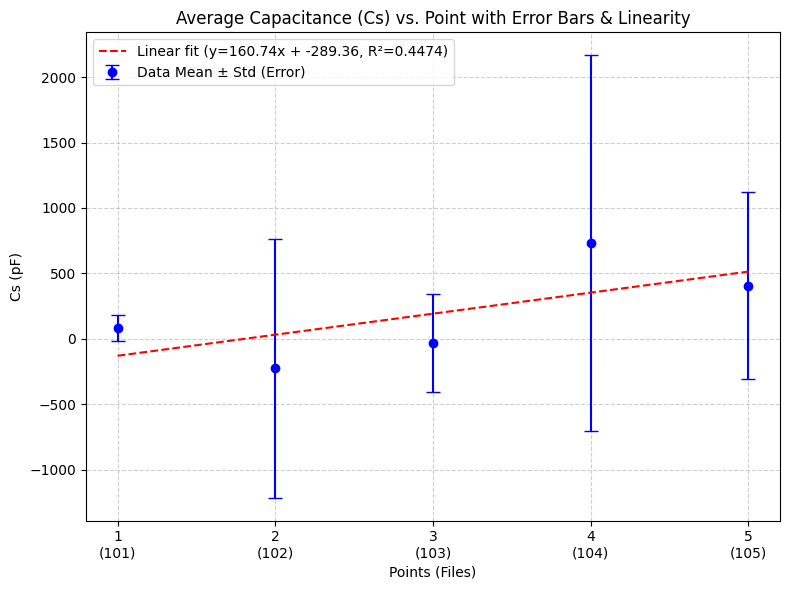

In [13]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def load_csvs_from_github(owner, repo, path, ref="main", token=None, session=None):
    session = session or requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower().endswith(".csv")]
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        try:
            # ใช้ skiprows=4 เพื่อข้ามบรรทัด Header ตั้งค่าของเครื่องมือวัด (เริ่มต้นอ่านที่ชื่อคอลัมน์)
            dfs[it["name"]] = pd.read_csv(url, skiprows=4)
            
            # ลบ Space ว่างที่ติดมากับชื่อคอลัมน์ เช่น ' Cs(F)-data' จะกลายเป็น 'Cs(F)-data'
            dfs[it["name"]].columns = dfs[it["name"]].columns.str.strip()
        except Exception as e:
            print(f"Failed to read {it['name']}: {e}")
    return dfs

# การเรียกใช้งานไฟล์จาก GitHub ตามโครงสร้างจริงของคุณ
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
subfolder = "FirstDataset/01"
dataframes = load_csvs_from_github(owner, repo, subfolder, ref="main", token=GITHUB_TOKEN)

# สร้างลิสต์ของชื่อไฟล์เพื่อให้ตรงกับจุดที่ต้องการ (1 ถึง 5)
sorted_files = ["101.CSV", "102.CSV", "103.CSV", "104.CSV", "105.CSV"]
x_values = []
y_means = []
y_errs = []

# ดึงข้อมูลจาก DataFrames มาคำนวณค่าเฉลี่ยและ Error (Standard Deviation)
for i, f in enumerate(sorted_files):
    if f in dataframes:
        x_val = i + 1
        x_values.append(x_val)
        
        # ปรับหน่วยจาก Farad เป็น picoFarad (pF) โดยการคูณ 1e12 
        # (เพราะค่าที่ได้มาอยู่ในระดับ e-10 ถึง e-12)
        mean_val = dataframes[f]['Cs(F)-data'].mean() * 1e12
        std_val = dataframes[f]['Cs(F)-data'].std() * 1e12
        
        y_means.append(mean_val)
        y_errs.append(std_val)

# หาค่า Linearity ด้วยสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x_values, y_means)
r_squared = r_value**2

print(f"Linearity (R-squared): {r_squared:.4f}")

# วาดกราฟ
fig, ax = plt.subplots(figsize=(8, 6))

# พล็อตกราฟค่าเฉลี่ยและใส่ Error bars
ax.errorbar(x_values, y_means, yerr=y_errs, fmt='o', capsize=5, color='blue', label='Data Mean ± Std (Error)')

# พล็อตเส้นแนวโน้ม (Linear Regression line)
trendline = [slope * x + intercept for x in x_values]
ax.plot(x_values, trendline, 'r--', label=f'Linear fit (y={slope:.2f}x + {intercept:.2f}, R²={r_squared:.4f})')

# ตั้งค่าแกน X ตามเงื่อนไขที่คุณต้องการ (จุด 1 คือ 101, ฯลฯ)
ax.set_xticks(x_values)
ax.set_xticklabels(['1\n(101)', '2\n(102)', '3\n(103)', '4\n(104)', '5\n(105)'])
ax.set_xlabel('Points (Files)')
ax.set_ylabel('Cs (pF)')
ax.set_title('Average Capacitance (Cs) vs. Point with Error Bars & Linearity')
ax.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Linearity (R-squared): 0.1147


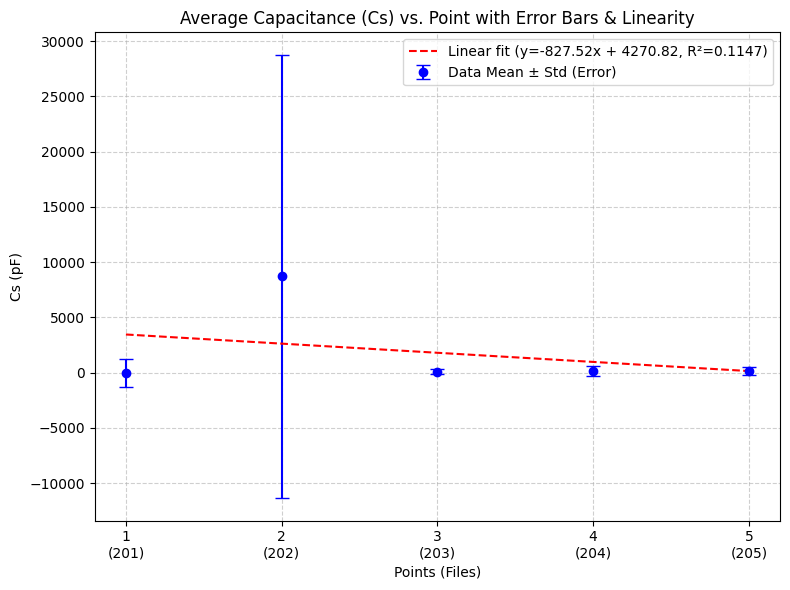

In [16]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def load_csvs_from_github(owner, repo, path, ref="main", token=None, session=None):
    session = session or requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower().endswith(".csv")]
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        try:
            # ใช้ skiprows=4 เพื่อข้ามบรรทัด Header ตั้งค่าของเครื่องมือวัด (เริ่มต้นอ่านที่ชื่อคอลัมน์)
            dfs[it["name"]] = pd.read_csv(url, skiprows=4)
            
            # ลบ Space ว่างที่ติดมากับชื่อคอลัมน์ เช่น ' Cs(F)-data' จะกลายเป็น 'Cs(F)-data'
            dfs[it["name"]].columns = dfs[it["name"]].columns.str.strip()
        except Exception as e:
            print(f"Failed to read {it['name']}: {e}")
    return dfs

# การเรียกใช้งานไฟล์จาก GitHub ตามโครงสร้างจริงของคุณ
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
subfolder = "FirstDataset/01"
dataframes = load_csvs_from_github(owner, repo, subfolder, ref="main", token=GITHUB_TOKEN)

# สร้างลิสต์ของชื่อไฟล์เพื่อให้ตรงกับจุดที่ต้องการ (1 ถึง 5)
sorted_files = ["201.CSV", "202.CSV", "203.CSV", "204.CSV", "205.CSV"]
x_values = []
y_means = []
y_errs = []

# ดึงข้อมูลจาก DataFrames มาคำนวณค่าเฉลี่ยและ Error (Standard Deviation)
for i, f in enumerate(sorted_files):
    if f in dataframes:
        x_val = i + 1
        x_values.append(x_val)
        
        # ปรับหน่วยจาก Farad เป็น picoFarad (pF) โดยการคูณ 1e12 
        # (เพราะค่าที่ได้มาอยู่ในระดับ e-10 ถึง e-12)
        mean_val = dataframes[f]['Cs(F)-data'].mean() * 1e12
        std_val = dataframes[f]['Cs(F)-data'].std() * 1e12
        
        y_means.append(mean_val)
        y_errs.append(std_val)

# หาค่า Linearity ด้วยสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x_values, y_means)
r_squared = r_value**2

print(f"Linearity (R-squared): {r_squared:.4f}")

# วาดกราฟ
fig, ax = plt.subplots(figsize=(8, 6))

# พล็อตกราฟค่าเฉลี่ยและใส่ Error bars
ax.errorbar(x_values, y_means, yerr=y_errs, fmt='o', capsize=5, color='blue', label='Data Mean ± Std (Error)')

# พล็อตเส้นแนวโน้ม (Linear Regression line)
trendline = [slope * x + intercept for x in x_values]
ax.plot(x_values, trendline, 'r--', label=f'Linear fit (y={slope:.2f}x + {intercept:.2f}, R²={r_squared:.4f})')

# ตั้งค่าแกน X ตามเงื่อนไขที่คุณต้องการ (จุด 1 คือ 201, ฯลฯ)
ax.set_xticks(x_values)
ax.set_xticklabels(['1\n(201)', '2\n(202)', '3\n(203)', '4\n(204)', '5\n(205)'])
ax.set_xlabel('Points (Files)')
ax.set_ylabel('Cs (pF)')
ax.set_title('Average Capacitance (Cs) vs. Point with Error Bars & Linearity')
ax.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Linearity (R-squared): 0.0000


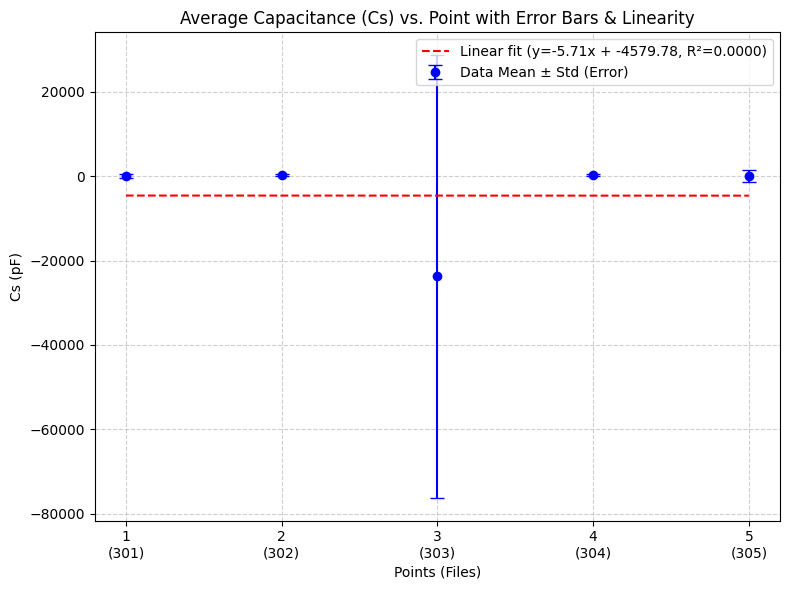

In [17]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def load_csvs_from_github(owner, repo, path, ref="main", token=None, session=None):
    session = session or requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower().endswith(".csv")]
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        try:
            # ใช้ skiprows=4 เพื่อข้ามบรรทัด Header ตั้งค่าของเครื่องมือวัด (เริ่มต้นอ่านที่ชื่อคอลัมน์)
            dfs[it["name"]] = pd.read_csv(url, skiprows=4)
            
            # ลบ Space ว่างที่ติดมากับชื่อคอลัมน์ เช่น ' Cs(F)-data' จะกลายเป็น 'Cs(F)-data'
            dfs[it["name"]].columns = dfs[it["name"]].columns.str.strip()
        except Exception as e:
            print(f"Failed to read {it['name']}: {e}")
    return dfs

# การเรียกใช้งานไฟล์จาก GitHub ตามโครงสร้างจริงของคุณ
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
subfolder = "FirstDataset/01"
dataframes = load_csvs_from_github(owner, repo, subfolder, ref="main", token=GITHUB_TOKEN)

# สร้างลิสต์ของชื่อไฟล์เพื่อให้ตรงกับจุดที่ต้องการ (1 ถึง 5)
sorted_files = ["301.CSV", "302.CSV", "303.CSV", "304.CSV", "305.CSV"]
x_values = []
y_means = []
y_errs = []

# ดึงข้อมูลจาก DataFrames มาคำนวณค่าเฉลี่ยและ Error (Standard Deviation)
for i, f in enumerate(sorted_files):
    if f in dataframes:
        x_val = i + 1
        x_values.append(x_val)
        
        # ปรับหน่วยจาก Farad เป็น picoFarad (pF) โดยการคูณ 1e12 
        # (เพราะค่าที่ได้มาอยู่ในระดับ e-10 ถึง e-12)
        mean_val = dataframes[f]['Cs(F)-data'].mean() * 1e12
        std_val = dataframes[f]['Cs(F)-data'].std() * 1e12
        
        y_means.append(mean_val)
        y_errs.append(std_val)

# หาค่า Linearity ด้วยสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x_values, y_means)
r_squared = r_value**2

print(f"Linearity (R-squared): {r_squared:.4f}")

# วาดกราฟ
fig, ax = plt.subplots(figsize=(8, 6))

# พล็อตกราฟค่าเฉลี่ยและใส่ Error bars
ax.errorbar(x_values, y_means, yerr=y_errs, fmt='o', capsize=5, color='blue', label='Data Mean ± Std (Error)')

# พล็อตเส้นแนวโน้ม (Linear Regression line)
trendline = [slope * x + intercept for x in x_values]
ax.plot(x_values, trendline, 'r--', label=f'Linear fit (y={slope:.2f}x + {intercept:.2f}, R²={r_squared:.4f})')

# ตั้งค่าแกน X ตามเงื่อนไขที่คุณต้องการ (จุด 1 คือ 301,_ ฯลฯ)
ax.set_xticks(x_values)
ax.set_xticklabels(['1\n(301)', '2\n(302)', '3\n(303)', '4\n(304)', '5\n(305)'])
ax.set_xlabel('Points (Files)')
ax.set_ylabel('Cs (pF)')
ax.set_title('Average Capacitance (Cs) vs. Point with Error Bars & Linearity')
ax.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Linearity (R-squared): 0.7248


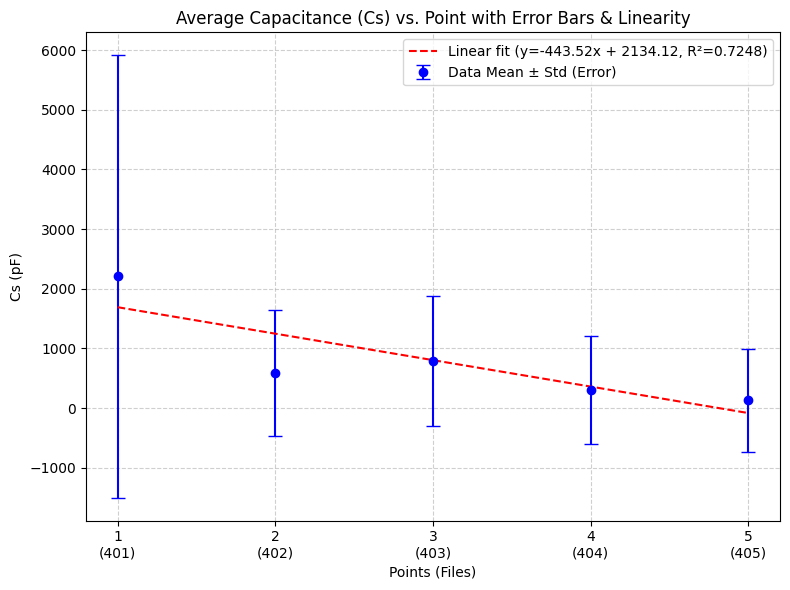

In [18]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def load_csvs_from_github(owner, repo, path, ref="main", token=None, session=None):
    session = session or requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower().endswith(".csv")]
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        try:
            # ใช้ skiprows=4 เพื่อข้ามบรรทัด Header ตั้งค่าของเครื่องมือวัด (เริ่มต้นอ่านที่ชื่อคอลัมน์)
            dfs[it["name"]] = pd.read_csv(url, skiprows=4)
            
            # ลบ Space ว่างที่ติดมากับชื่อคอลัมน์ เช่น ' Cs(F)-data' จะกลายเป็น 'Cs(F)-data'
            dfs[it["name"]].columns = dfs[it["name"]].columns.str.strip()
        except Exception as e:
            print(f"Failed to read {it['name']}: {e}")
    return dfs

# การเรียกใช้งานไฟล์จาก GitHub ตามโครงสร้างจริงของคุณ
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
subfolder = "FirstDataset/01"
dataframes = load_csvs_from_github(owner, repo, subfolder, ref="main", token=GITHUB_TOKEN)

# สร้างลิสต์ของชื่อไฟล์เพื่อให้ตรงกับจุดที่ต้องการ (1 ถึง 5)
sorted_files = ["401.CSV", "402.CSV", "403.CSV", "404.CSV", "405.CSV"]
x_values = []
y_means = []
y_errs = []

# ดึงข้อมูลจาก DataFrames มาคำนวณค่าเฉลี่ยและ Error (Standard Deviation)
for i, f in enumerate(sorted_files):
    if f in dataframes:
        x_val = i + 1
        x_values.append(x_val)
        
        # ปรับหน่วยจาก Farad เป็น picoFarad (pF) โดยการคูณ 1e12 
        # (เพราะค่าที่ได้มาอยู่ในระดับ e-10 ถึง e-12)
        mean_val = dataframes[f]['Cs(F)-data'].mean() * 1e12
        std_val = dataframes[f]['Cs(F)-data'].std() * 1e12
        
        y_means.append(mean_val)
        y_errs.append(std_val)

# หาค่า Linearity ด้วยสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x_values, y_means)
r_squared = r_value**2

print(f"Linearity (R-squared): {r_squared:.4f}")

# วาดกราฟ
fig, ax = plt.subplots(figsize=(8, 6))

# พล็อตกราฟค่าเฉลี่ยและใส่ Error bars
ax.errorbar(x_values, y_means, yerr=y_errs, fmt='o', capsize=5, color='blue', label='Data Mean ± Std (Error)')

# พล็อตเส้นแนวโน้ม (Linear Regression line)
trendline = [slope * x + intercept for x in x_values]
ax.plot(x_values, trendline, 'r--', label=f'Linear fit (y={slope:.2f}x + {intercept:.2f}, R²={r_squared:.4f})')

# ตั้งค่าแกน X ตามเงื่อนไขที่คุณต้องการ (จุด 1 คือ 401, ฯลฯ)
ax.set_xticks(x_values)
ax.set_xticklabels(['1\n(401)', '2\n(402)', '3\n(403)', '4\n(404)', '5\n(405)'])
ax.set_xlabel('Points (Files)')
ax.set_ylabel('Cs (pF)')
ax.set_title('Average Capacitance (Cs) vs. Point with Error Bars & Linearity')
ax.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()